In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [ ]:
train.head()


In [ ]:
test.head()

In [5]:
### Check Dataset Shape

In [67]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [68]:
train_df = train.copy()
test_df = test.copy()

In [69]:
print(train.shape)
print(train_df.shape)

print(test.shape)
print(test_df.shape)

(1460, 81)
(1460, 81)
(1459, 80)
(1459, 80)


In [70]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [71]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [72]:
train_df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [73]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [74]:
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [75]:
missing_cols = train_df.columns[train_df.isnull().any()]

categorical_missing = train_df[missing_cols].select_dtypes(include="object").columns
numerical_missing = train_df[missing_cols].select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_missing)

print("\nNumerical Columns:")
print(numerical_missing)

Categorical Columns:
Index(['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature'],
      dtype='object')

Numerical Columns:
Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')


#### "I first checked why the values were missing. 
#### For columns like GarageType, PoolQC, FireplaceQu, and Alley, the missing value doesn't 
#### mean the data is lost. It means the house doesn't have that feature. So I replaced NaN with 'None' to clearly represent 'feature not present'."

In [76]:
none_cols = [
    "Alley",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

train_df[none_cols] = train_df[none_cols].fillna("None")

In [77]:
train_df[none_cols].isnull().sum()

Alley           0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64

In [78]:
### Now let's do ONLY ONE COLUMN: Electrical
train_df["Electrical"].value_counts(dropna=False)


Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

In [79]:
"Electrical" in train_df.columns

True

In [80]:
train_df["Electrical"].head(10)

0    SBrkr
1    SBrkr
2    SBrkr
3    SBrkr
4    SBrkr
5    SBrkr
6    SBrkr
7    SBrkr
8    FuseF
9    SBrkr
Name: Electrical, dtype: object

In [81]:
train_df["Electrical"] = train_df["Electrical"].fillna(
    train_df["Electrical"].mode()[0]
)
train_df["Electrical"]

0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
        ...  
1455    SBrkr
1456    SBrkr
1457    SBrkr
1458    FuseA
1459    SBrkr
Name: Electrical, Length: 1460, dtype: object

In [82]:
train_df["Electrical"].isnull().sum()

np.int64(0)

In [83]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [84]:
train_df["MasVnrType"] = train_df["MasVnrType"].fillna("None")

In [85]:
train_df["MasVnrType"].isnull().sum()

np.int64(0)

In [86]:
train_df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [87]:
categorical_cols = train_df.select_dtypes(include="object").columns
numerical_cols = train_df.select_dtypes(exclude="object").columns

In [88]:
train_df[categorical_cols].isnull().sum()

MSZoning         0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
PoolQC           0
Fence            0
MiscFeature      0
SaleType         0
SaleCondition    0
dtype: int64

In [89]:
train_df[numerical_cols].isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [90]:
train_df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

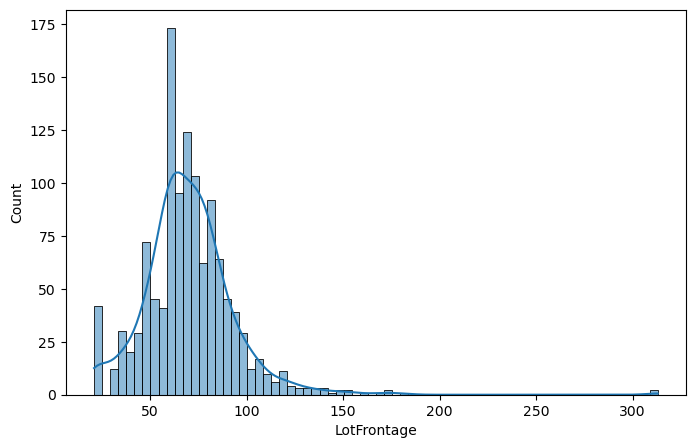

In [91]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["LotFrontage"], kde=True)
plt.show()

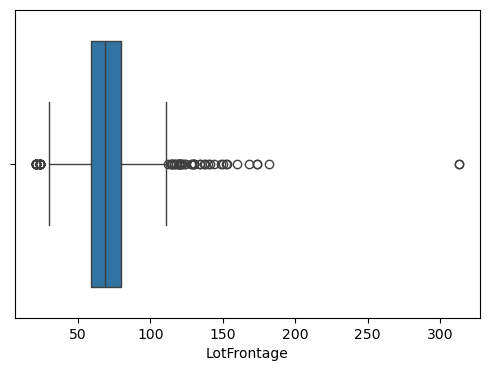

In [92]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train_df["LotFrontage"])
plt.show()

In [93]:
train_df["LotFrontage"] = train_df["LotFrontage"].fillna(
    train_df["LotFrontage"].median()
)

In [94]:
train_df["LotFrontage"].isnull().sum()

np.int64(0)

1. Understand the column
2. Check missing values
3. Plot histogram
4. Plot box plot
5. Decide Mean or Median
6. Fill missing values
7. Verify

In [95]:
train_df["MasVnrArea"].describe()

count    1452.000000
mean      103.685262
std       181.066207
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1600.000000
Name: MasVnrArea, dtype: float64

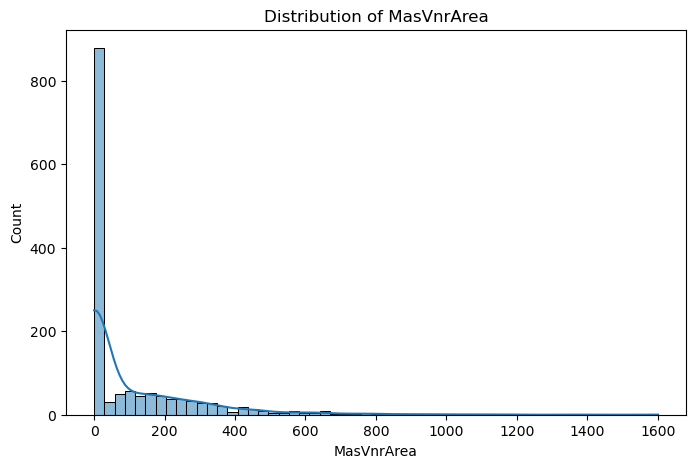

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["MasVnrArea"], kde=True)
plt.title("Distribution of MasVnrArea")
plt.show()

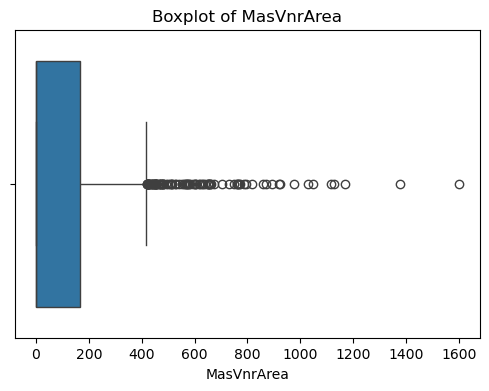

In [97]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train_df["MasVnrArea"])
plt.title("Boxplot of MasVnrArea")
plt.show()

In [98]:
train_df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [99]:
train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(
    train_df["MasVnrArea"].median()
)

In [100]:
train_df["MasVnrArea"].isnull().sum()

np.int64(0)

In [101]:
train_df["GarageYrBlt"].describe()

count    1379.000000
mean     1978.506164
std        24.689725
min      1900.000000
25%      1961.000000
50%      1980.000000
75%      2002.000000
max      2010.000000
Name: GarageYrBlt, dtype: float64

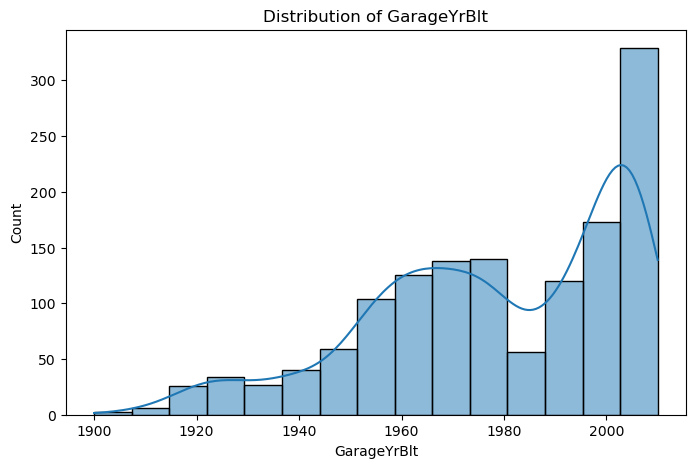

In [102]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["GarageYrBlt"], kde=True)
plt.title("Distribution of GarageYrBlt")
plt.show()

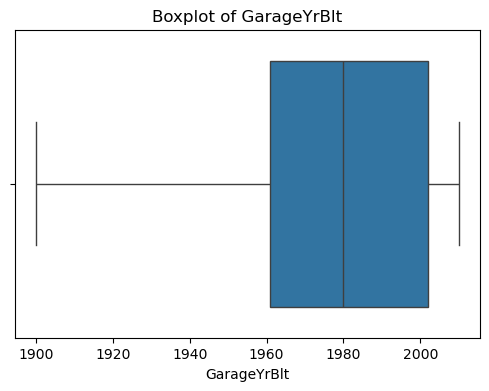

In [103]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train_df["GarageYrBlt"])
plt.title("Boxplot of GarageYrBlt")
plt.show()

In [104]:
train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(
    train_df["GarageYrBlt"].mean()
)

In [105]:
train_df["GarageYrBlt"].isnull().sum()

np.int64(0)

In [106]:
train_df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [107]:
train_df.isnull().sum()[train_df.isnull().sum() > 0]

Series([], dtype: int64)

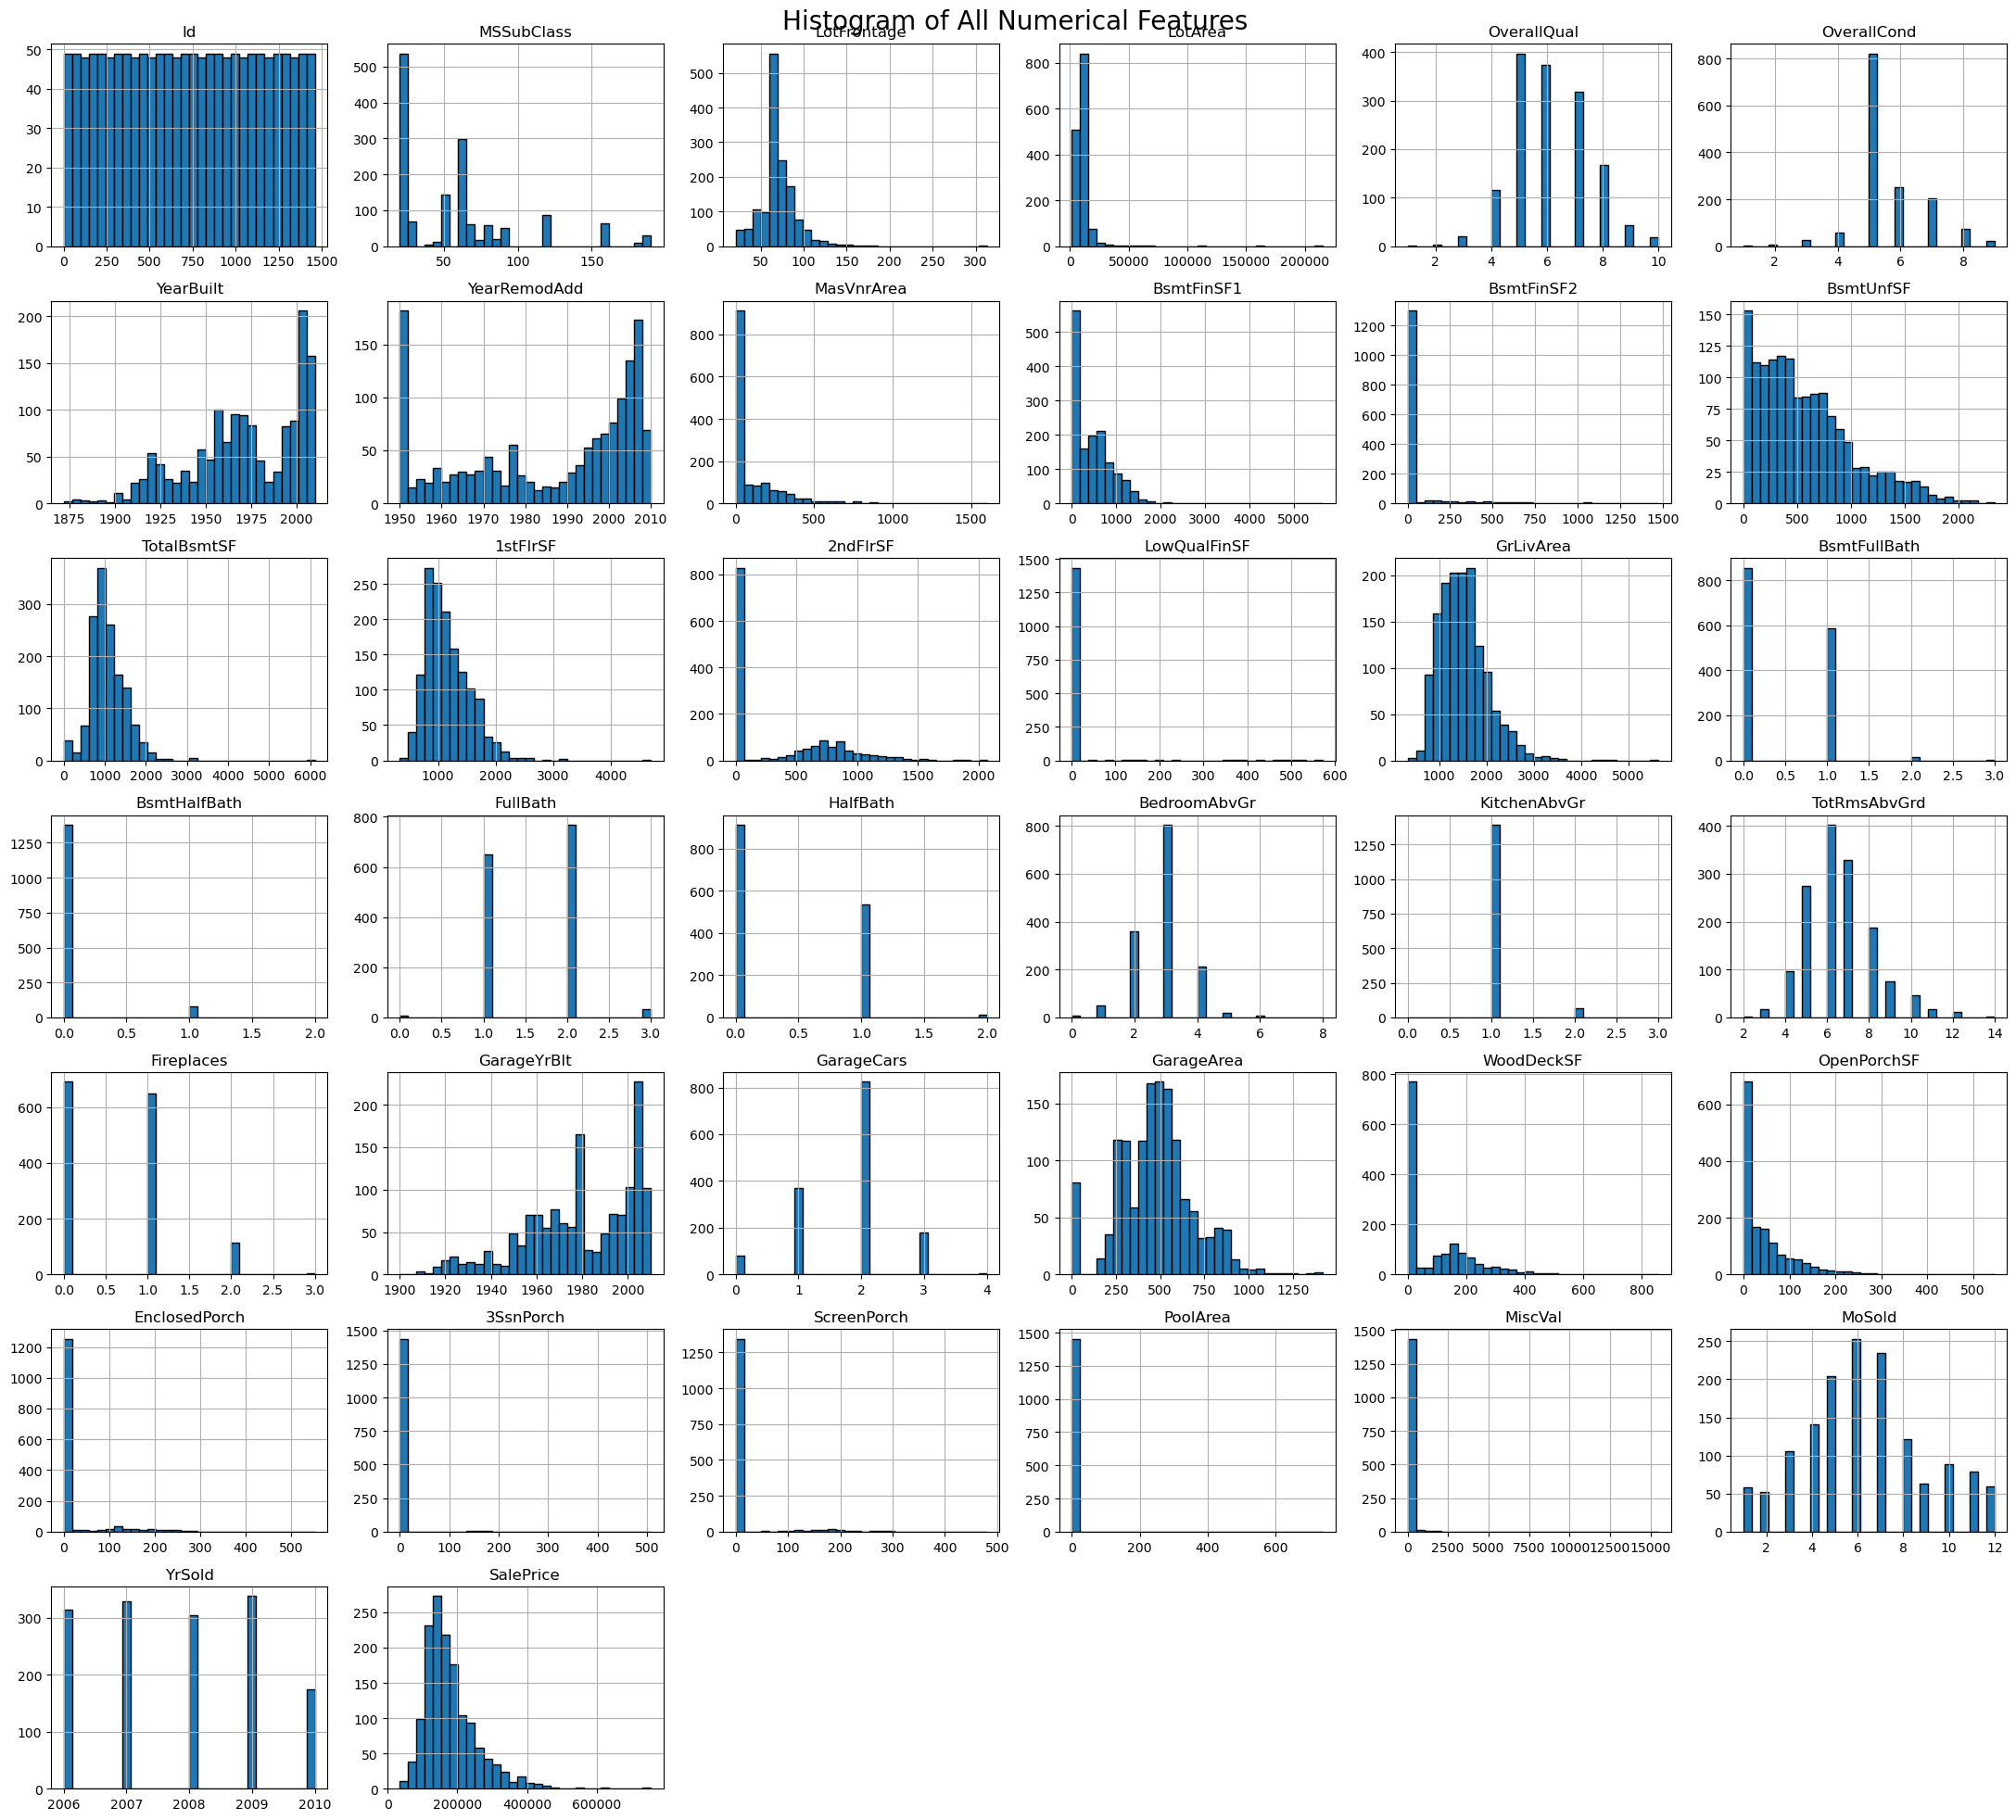

In [109]:
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# Plot all histograms
train_df[numerical_cols].hist(
    bins=30,
    figsize=(22, 20),
    edgecolor='black'
)

plt.suptitle("Histogram of All Numerical Features", fontsize=20)
plt.tight_layout()
plt.show()

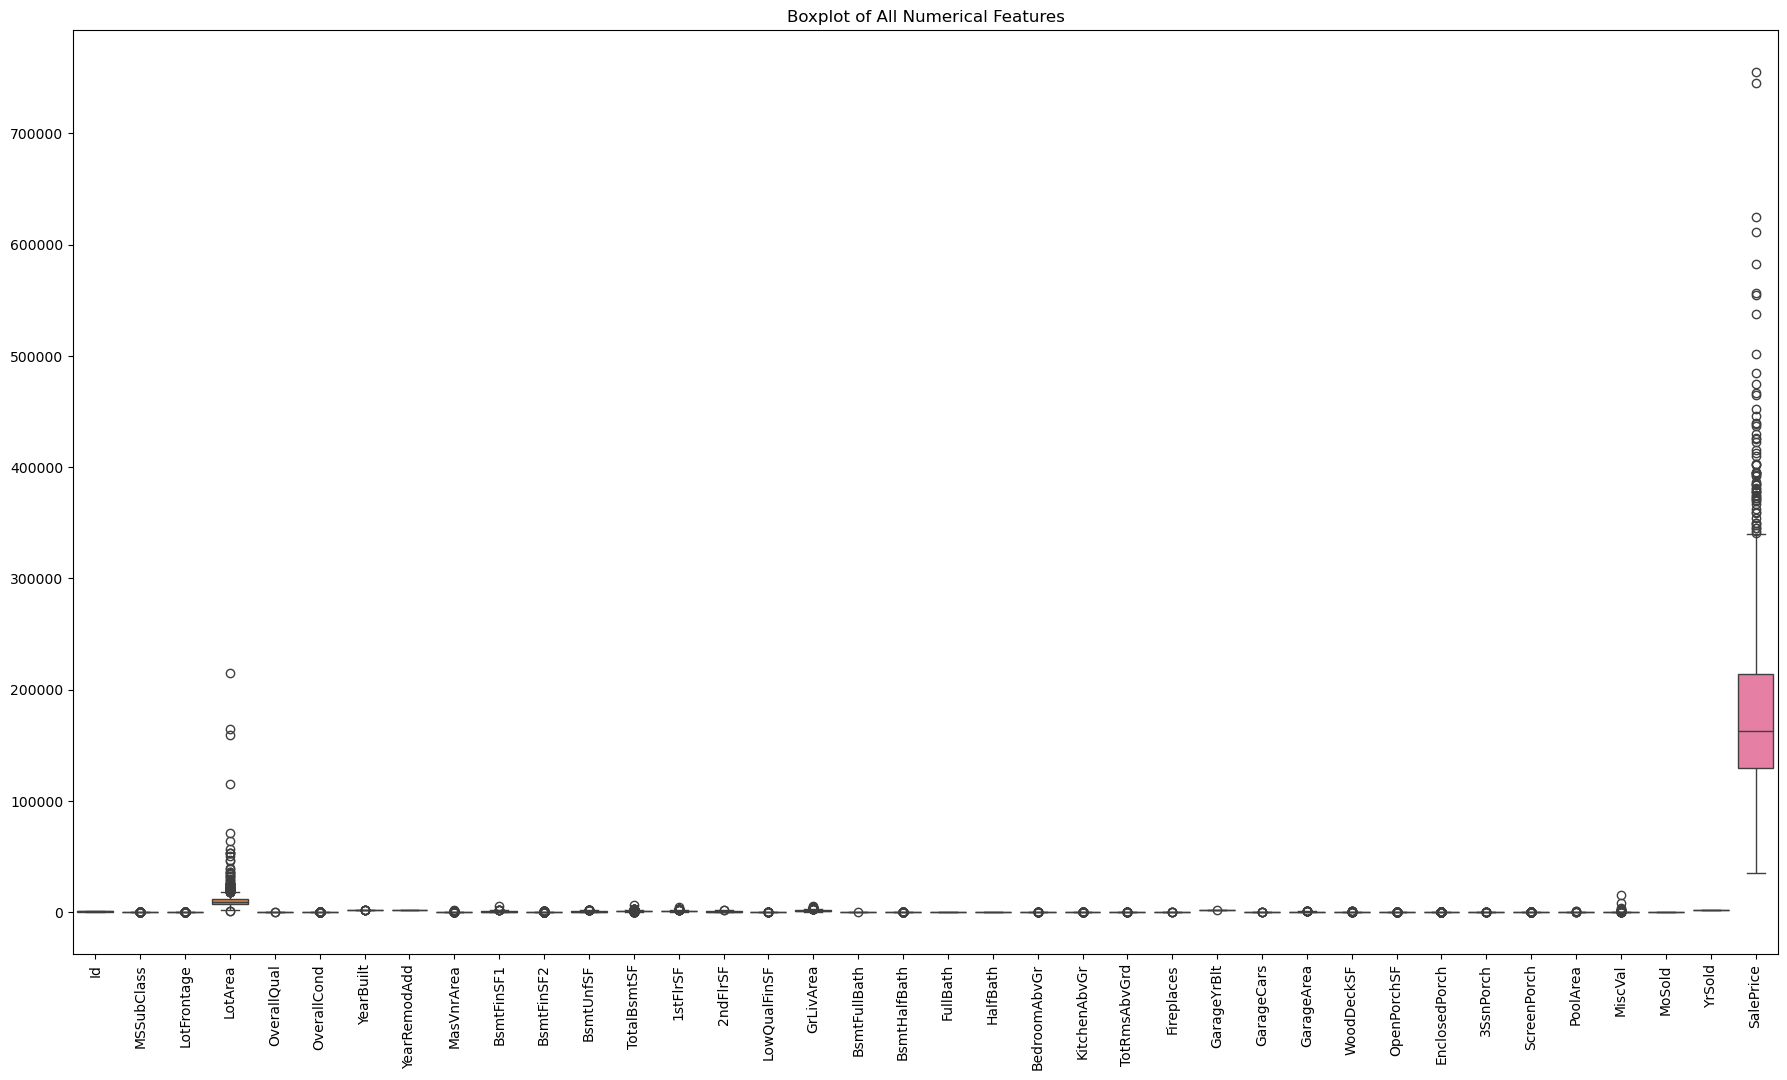

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,12))

sns.boxplot(data=train_df.select_dtypes(include=['int64','float64']))

plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")

plt.show()

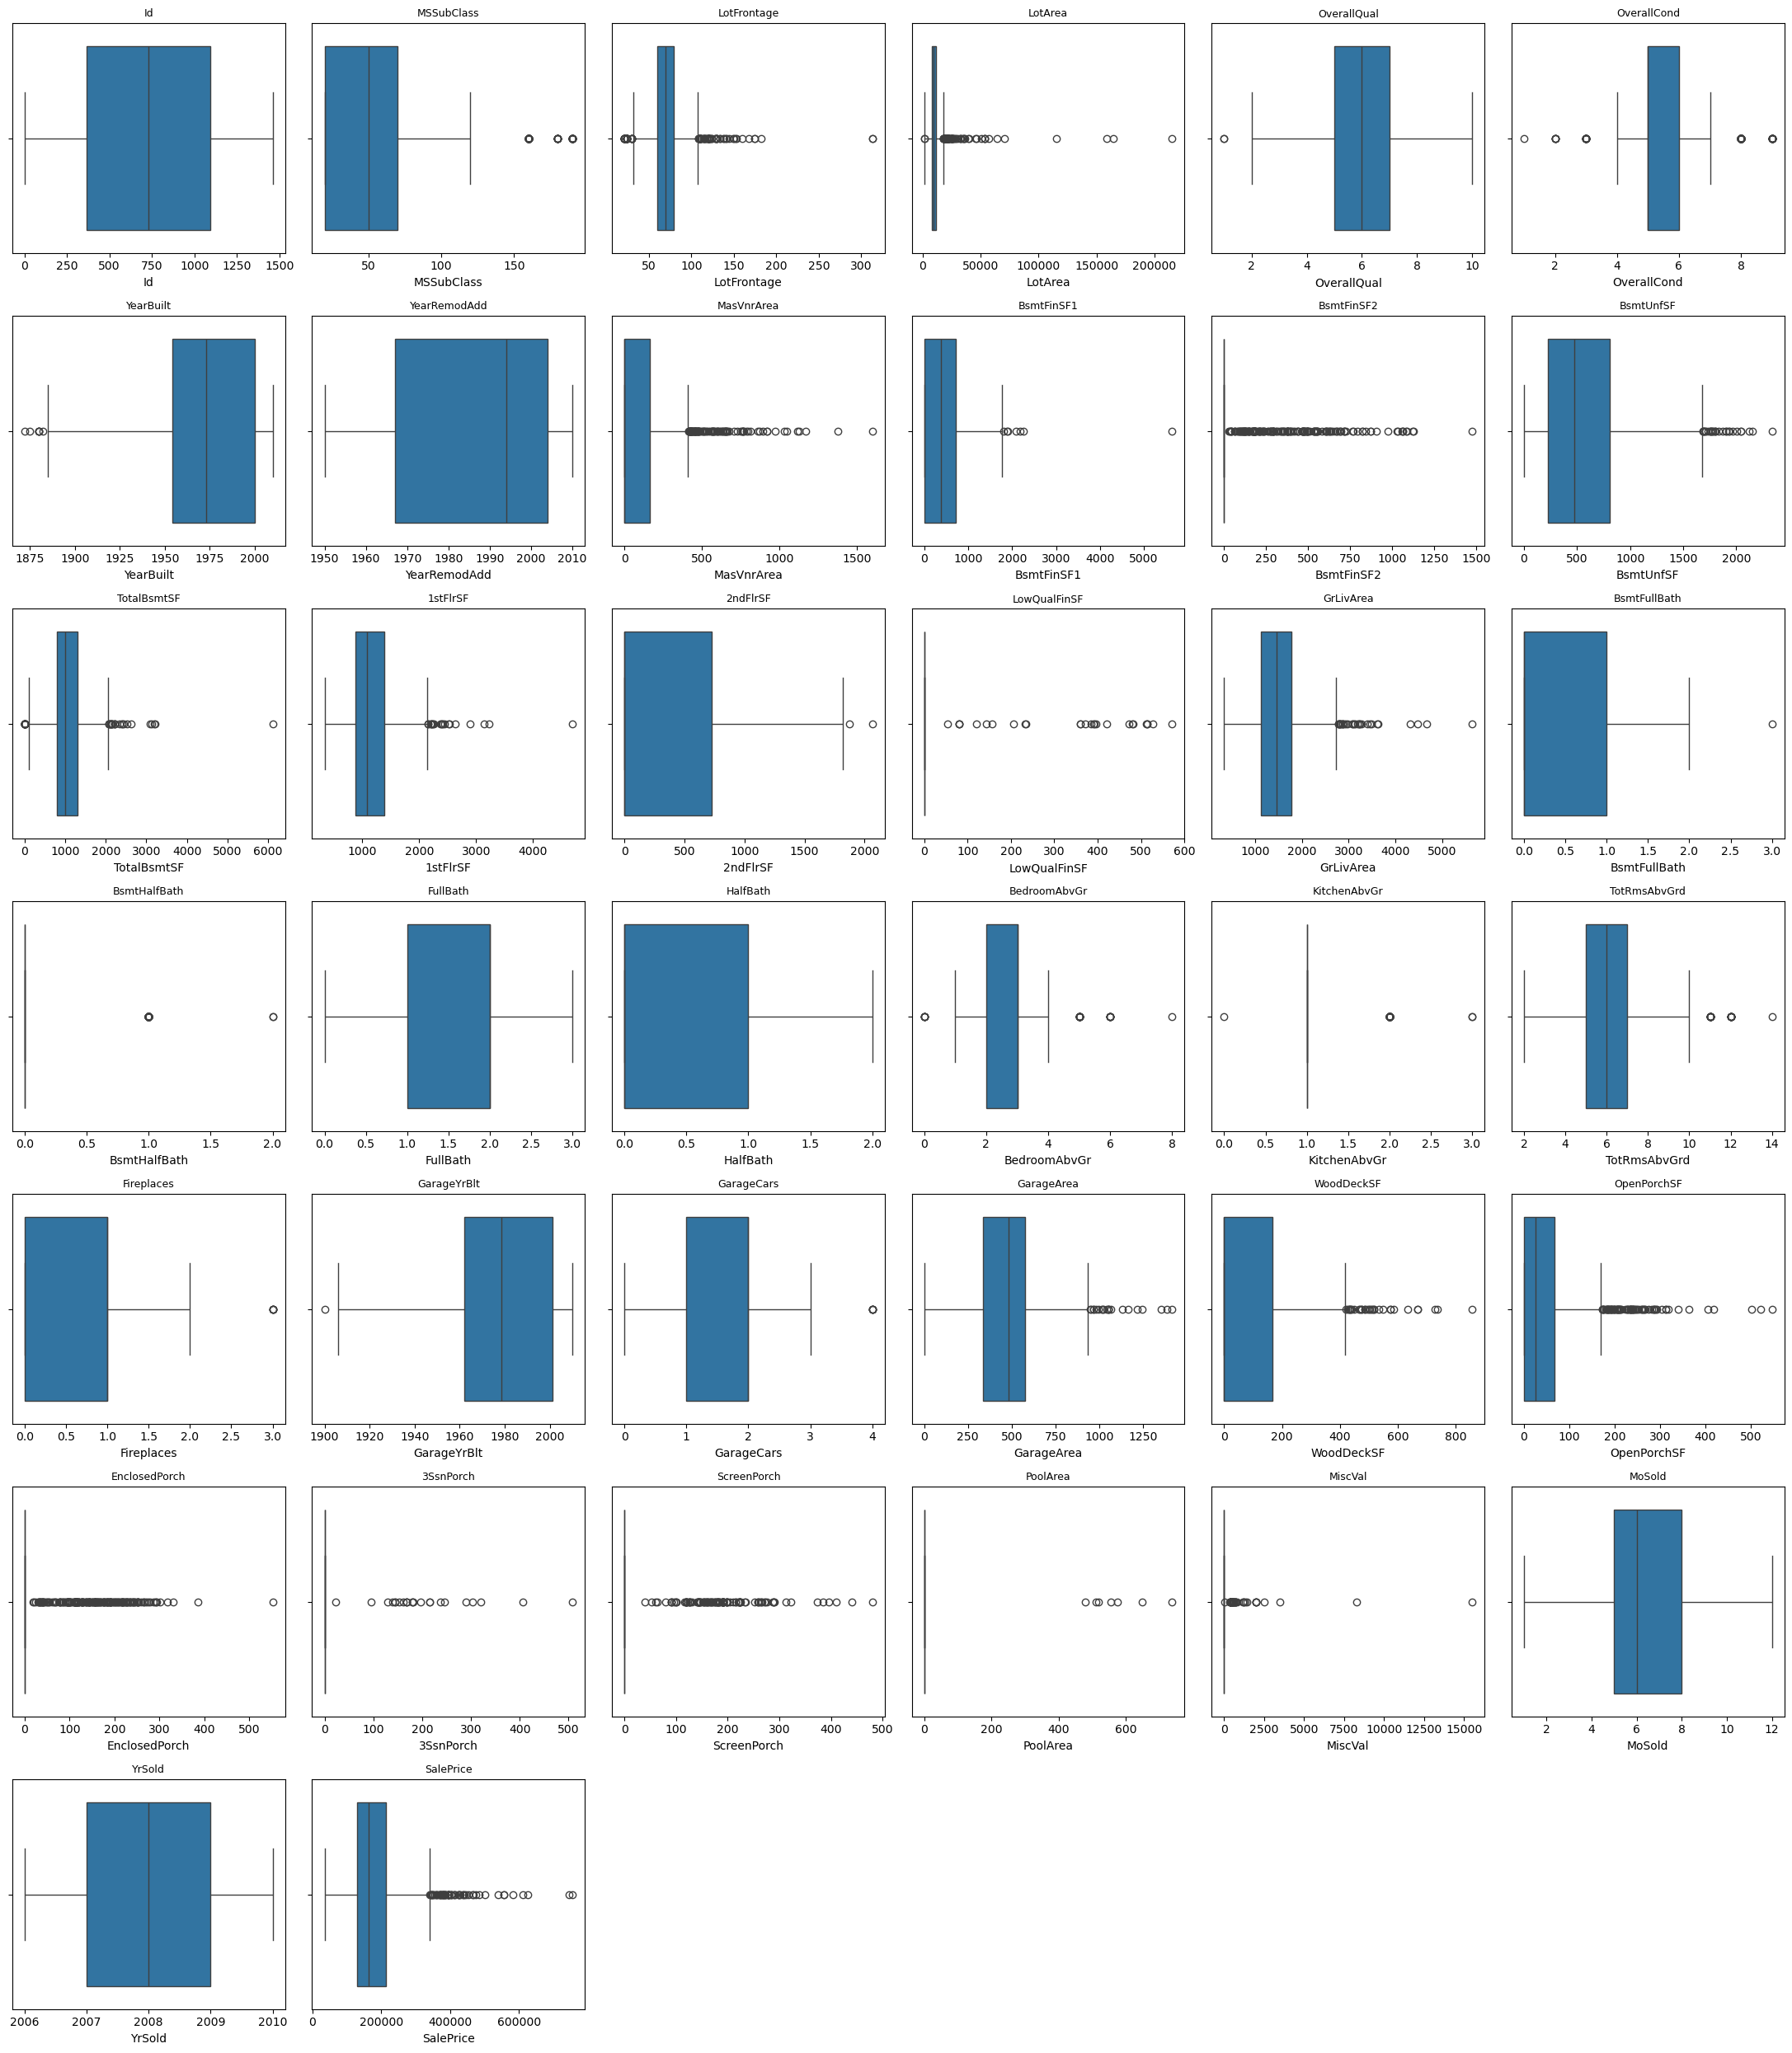

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = train_df.select_dtypes(include=['int64','float64']).columns

fig, axes = plt.subplots(7, 6, figsize=(22, 25))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=train_df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)

# Hide unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [115]:
outlier_summary = []

numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]

    outlier_summary.append([col, len(outliers)])

outlier_df = pd.DataFrame(outlier_summary, columns=["Feature", "Outlier_Count"])

outlier_df.sort_values(by="Outlier_Count", ascending=False)

,Feature,Outlier_Count
30,EnclosedPorch,208
10,BsmtFinSF2,167
5,OverallCond,125
32,ScreenPorch,116
2,LotFrontage,104
1,MSSubClass,103
8,MasVnrArea,97
18,BsmtHalfBath,82
29,OpenPorchSF,75
22,KitchenAbvGr,68


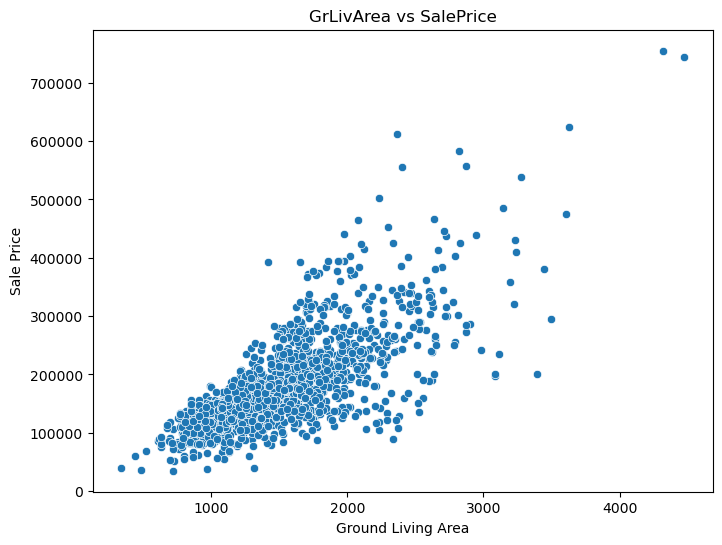

In [116]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=train_df["GrLivArea"],
    y=train_df["SalePrice"]
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

In [117]:
train_df = train_df.drop(
    train_df[
        (train_df["GrLivArea"] > 4000) &
        (train_df["SalePrice"] < 300000)
    ].index
)

In [118]:
corr = train_df.corr(numeric_only=True)

saleprice_corr = corr["SalePrice"].sort_values(ascending=False)

saleprice_corr

SalePrice        1.000000
OverallQual      0.795774
GrLivArea        0.734968
TotalBsmtSF      0.651153
GarageCars       0.641047
1stFlrSF         0.631530
GarageArea       0.629217
FullBath         0.562165
TotRmsAbvGrd     0.537769
YearBuilt        0.523608
YearRemodAdd     0.507717
MasVnrArea       0.477810
GarageYrBlt      0.470844
Fireplaces       0.469862
BsmtFinSF1       0.409384
LotFrontage      0.352688
WoodDeckSF       0.324758
OpenPorchSF      0.321142
2ndFlrSF         0.320532
HalfBath         0.284590
LotArea          0.268179
BsmtFullBath     0.228459
BsmtUnfSF        0.214460
BedroomAbvGr     0.168245
ScreenPorch      0.111415
PoolArea         0.099490
MoSold           0.046124
3SsnPorch        0.044568
BsmtFinSF2      -0.011422
BsmtHalfBath    -0.016881
MiscVal         -0.021203
Id              -0.021673
LowQualFinSF    -0.025625
YrSold          -0.028882
OverallCond     -0.077948
MSSubClass      -0.084276
EnclosedPorch   -0.128646
KitchenAbvGr    -0.135946
Name: SalePr

#### Feature Engineering
#### Feature Engineering is the process of creating new, meaningful features from existing features to improve the performance of a machine learning model.

In [119]:
train_df["TotalSF"] = (
    train_df["TotalBsmtSF"]
    + train_df["1stFlrSF"]
    + train_df["2ndFlrSF"]
)

In [120]:
train_df[["TotalBsmtSF","1stFlrSF","2ndFlrSF","TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


##### We create TotalSF to get the total size of the house by adding the basement, first floor, and second floor areas.
##### A house's total area is more useful for predicting its price than looking at each floor separately.

In [121]:
### house age
train_df["HouseAge"] = (
    train_df["YrSold"]
    - train_df["YearBuilt"]
)

In [122]:
train_df[["YearBuilt", "YrSold", "HouseAge"]].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


#### "I created HouseAge by subtracting YearBuilt from YrSold.
#### It tells us how old the house was when it was sold. House age is more meaningful than the construction year and helps the Linear Regression model predict house prices better."

In [58]:
#### I created RemodelAge to know how many years have passed since the house was remodeled.
#### A recently remodeled house is usually worth more than a house that has not been remodeled for many years.

In [123]:
train_df["RemodelAge"] = (
    train_df["YrSold"]
    - train_df["YearRemodAdd"]
)

In [124]:
train_df[["YearRemodAdd", "YrSold", "RemodelAge"]].head()

,YearRemodAdd,YrSold,RemodelAge
0,2003,2008,5
1,1976,2007,31
2,2002,2008,6
3,1970,2006,36
4,2000,2008,8


In [61]:
### TotalBath

### "I combined all bathroom-related columns into one feature called TotalBath. 
### Half bathrooms were counted as 0.5 because they are smaller than full bathrooms. 
### This gives the model a better understanding of the total bathroom capacity of the house."

In [125]:
train_df["TotalBath"] = (
    train_df["FullBath"]
    + 0.5 * train_df["HalfBath"]
    + train_df["BsmtFullBath"]
    + 0.5 * train_df["BsmtHalfBath"]
)

In [126]:
train_df[[
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBath"
]].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBath
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


#### TotalPorchSF

In [127]:
train_df["TotalPorchSF"] = (
    train_df["OpenPorchSF"]
    + train_df["EnclosedPorch"]
    + train_df["3SsnPorch"]
    + train_df["ScreenPorch"]
)

In [128]:
train_df[[
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "TotalPorchSF"
]].head()

,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,TotalPorchSF
0,61,0,0,0,61
1,0,0,0,0,0
2,42,0,0,0,42
3,35,272,0,0,307
4,84,0,0,0,84


###Encoding
--- Encoding is the process of converting text (categorical data) into numbers so that a Machine Learning model can understand it.
----- "Linear Regression cannot understand text values. I used One-Hot Encoding to convert categorical columns into numerical columns. 
----  "I also used drop_first=True to avoid the dummy variable trap and reduce multicollinearity."

In [129]:
categorical_cols = train_df.select_dtypes(include="object").columns

print(categorical_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [130]:
len(categorical_cols)

43

In [131]:
train_df = pd.get_dummies(
    train_df,
    columns=categorical_cols,
    drop_first=True
)

In [132]:
train_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [133]:
import numpy as np

train_df["SalePrice"] = np.log1p(train_df["SalePrice"])

#### Feature Selection means choosing the input columns (X) and the target column (y) for the machine learning model.

In [134]:
# Feature Selection

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (1458, 264)
y Shape : (1458,)


Train-Test Split is the process of dividing the dataset into two parts:

Training Data → Used to teach the model.
Testing Data → Used to check how well the model learned.

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (1166, 264)
X_test : (292, 264)
y_train : (1166,)
y_test : (292,)


In [ ]:
###Linear Regression is a Supervised Machine Learning algorithm used to predict continuous numerical values.

In [136]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully!")
y_pred = model.predict(X_test)


Model Trained Successfully!


In [137]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression Results")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)



Linear Regression Results
-------------------------
MAE  : 0.09341783034607024
MSE  : 0.018813921687558265
RMSE : 0.13716384978396554
R2 Score : 0.8883951912752405


In [138]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(comparison.head(10))

      Actual Price  Predicted Price
1322     12.154785        12.320585
837      11.512935        11.516304
413      11.652696        11.530325
522      11.976666        12.000573
1036     12.661917        12.659092
615      11.831386        11.897722
218      12.649158        12.405299
1032     12.644331        12.656372
1289     12.546114        12.577728
887      11.816734        11.880441


In [139]:
print(X_train.shape)
print(X_test.shape)

print(X_train.dtypes.value_counts())

print(train_df["SalePrice"].describe())

(1166, 264)
(292, 264)
bool       222
int64       38
float64      4
Name: count, dtype: int64
count    1458.000000
mean       12.024015
std         0.399713
min        10.460271
25%        11.774720
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64


In [ ]:
import numpy as np

print(np.isinf(X_train).sum().sum())
print(np.isinf(X_test).sum().sum())

In [140]:
print(train_df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [141]:
print(X_train.columns.equals(X_test.columns))

True


In [142]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9527136798242308
0.8883951912752405


In [143]:
print(X_train.shape)
print(X_test.shape)

(1166, 264)
(292, 264)


In [144]:
print(len(model.coef_))

264


In [145]:
import pandas as pd

corr = X_train.corr().abs()

high_corr = (
    corr.where(corr > 0.95)
        .stack()
        .reset_index()
)

high_corr.columns = ["Feature1", "Feature2", "Correlation"]

high_corr = high_corr[high_corr["Feature1"] != high_corr["Feature2"]]

print(high_corr.head(20))

                Feature1             Feature2  Correlation
7              YearBuilt             HouseAge     0.999037
9           YearRemodAdd           RemodelAge     0.997925
36              PoolArea          PoolQC_None     0.989502
41              HouseAge            YearBuilt     0.999037
43            RemodelAge         YearRemodAdd     0.997925
131   Exterior1st_CBlock   Exterior2nd_CBlock     1.000000
133  Exterior1st_CemntBd  Exterior2nd_CmentBd     0.966463
137  Exterior1st_MetalSd  Exterior2nd_MetalSd     0.978721
142  Exterior1st_VinylSd  Exterior2nd_VinylSd     0.977399
148   Exterior2nd_CBlock   Exterior1st_CBlock     1.000000
150  Exterior2nd_CmentBd  Exterior1st_CemntBd     0.966463
154  Exterior2nd_MetalSd  Exterior1st_MetalSd     0.978721
160  Exterior2nd_VinylSd  Exterior1st_VinylSd     0.977399
182        BsmtQual_None        BsmtCond_None     1.000000
183        BsmtQual_None    BsmtExposure_None     1.000000
184        BsmtQual_None    BsmtFinType1_None     1.0000

In [146]:
import numpy as np

comparison = pd.DataFrame({
    "Actual Price": np.expm1(y_test),
    "Predicted Price": np.expm1(y_pred)
})

print(comparison.head(10))

      Actual Price  Predicted Price
1322      190000.0    224264.229464
837       100000.0    100337.466200
413       115000.0    101754.131360
522       159000.0    162847.138794
1036      315500.0    314609.933424
615       137500.0    146930.478165
218       311500.0    244090.533711
1032      310000.0    313755.489500
1289      281000.0    290025.736481
887       135500.0    144413.179744


In [147]:
##Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

In [148]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2 Score :", ridge_r2)

Ridge Regression Results
------------------------
MAE : 0.0872287089774345
MSE : 0.0160854276569201
RMSE : 0.12682833932887436
R2 Score : 0.9045807085455391


In [149]:
comparison = pd.DataFrame({
    "Actual Price": np.expm1(y_test),
    "Predicted Price": np.expm1(ridge_pred)
})

print(comparison.head(10))

      Actual Price  Predicted Price
1322      190000.0    226262.947185
837       100000.0    101100.621184
413       115000.0    101094.557543
522       159000.0    163038.264706
1036      315500.0    310118.489616
615       137500.0    148073.682577
218       311500.0    240986.638229
1032      310000.0    313738.921345
1289      281000.0    288537.016454
887       135500.0    145139.191970


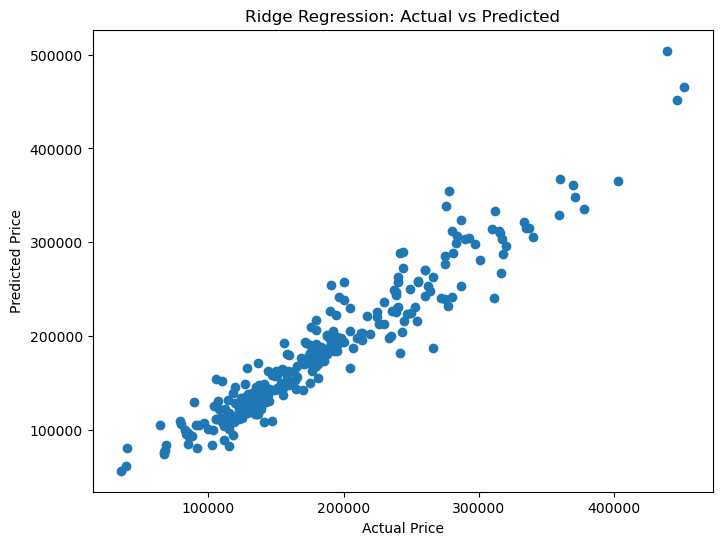

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(np.expm1(y_test), np.expm1(ridge_pred))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

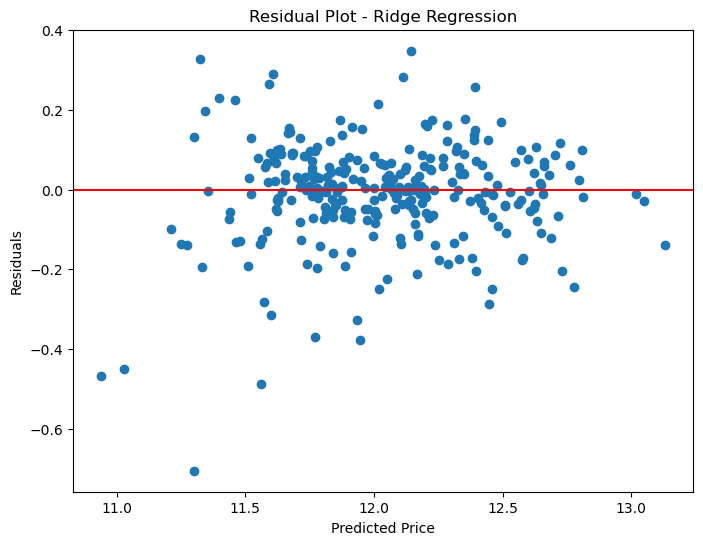

In [151]:
residuals = y_test - ridge_pred

plt.figure(figsize=(8,6))
plt.scatter(ridge_pred, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Ridge Regression")
plt.show()

In [152]:
### Lasso Regression
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.0001)

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Results")
print("------------------------")
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R2 Score :", lasso_r2)

Lasso Regression Results
------------------------
MAE : 0.08612756345682522
MSE : 0.015387084500809552
RMSE : 0.12404468751546578
R2 Score : 0.9087233033567795


In [154]:
comparison = pd.DataFrame({
    "Actual Price": np.expm1(y_test),
    "Predicted Price": np.expm1(lasso_pred)
})

print(comparison.head(10))

      Actual Price  Predicted Price
1322      190000.0    225773.176609
837       100000.0    101808.822280
413       115000.0    101080.981580
522       159000.0    161145.338900
1036      315500.0    312795.267561
615       137500.0    147299.045453
218       311500.0    241446.117626
1032      310000.0    313080.348429
1289      281000.0    287807.749583
887       135500.0    145039.377196


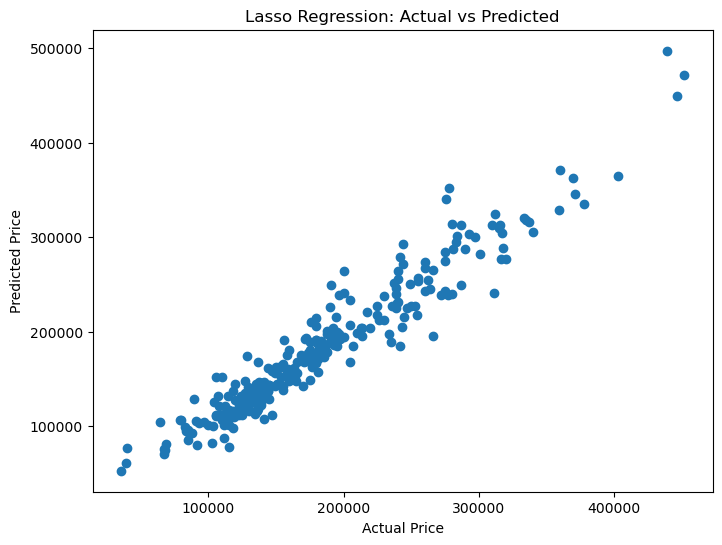

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(np.expm1(y_test), np.expm1(lasso_pred))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

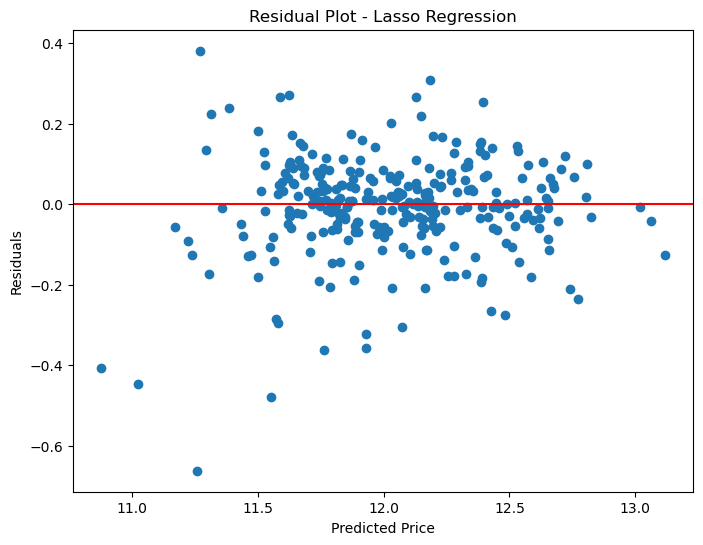

In [156]:
residuals = y_test - lasso_pred

plt.figure(figsize=(8,6))
plt.scatter(lasso_pred, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Lasso Regression")
plt.show()

In [157]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MAE": [mae, ridge_mae, lasso_mae],
    "MSE": [mse, ridge_mse, lasso_mse],
    "RMSE": [rmse, ridge_rmse, lasso_rmse],
    "R2 Score": [r2, ridge_r2, lasso_r2]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.093418,0.018814,0.137164,0.888395
1,Ridge Regression,0.087229,0.016085,0.126828,0.904581
2,Lasso Regression,0.086128,0.015387,0.124045,0.908723


In [158]:
print("Model Comparison")
print("=" * 60)
print(comparison)

Model Comparison
               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  0.093418  0.018814  0.137164  0.888395
1   Ridge Regression  0.087229  0.016085  0.126828  0.904581
2   Lasso Regression  0.086128  0.015387  0.124045  0.908723


In [159]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("\nBest Model")
print("=" * 30)
print(best_model)


Best Model
Model       Lasso Regression
MAE                 0.086128
MSE                 0.015387
RMSE                0.124045
R2 Score            0.908723
Name: 2, dtype: object


#### test data


import os

print(os.getcwd())

In [162]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'House_price.ipynb']


In [164]:
import pandas as pd

test_df = pd.read_csv("../data/test.csv")

print(test_df.shape)
test_df.head()

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


##### Feature Engineering

--- You already created these in train_df, so create them in test_df too.

In [170]:
test_df["TotalSF"] = (
    test_df["TotalBsmtSF"]
    + test_df["1stFlrSF"]
    + test_df["2ndFlrSF"]
)

test_df["HouseAge"] = test_df["YrSold"] - test_df["YearBuilt"]

test_df["RemodelAge"] = test_df["YrSold"] - test_df["YearRemodAdd"]

test_df["TotalBath"] = (
    test_df["FullBath"]
    + 0.5 * test_df["HalfBath"]
    + test_df["BsmtFullBath"]
    + 0.5 * test_df["BsmtHalfBath"]
)

test_df["TotalPorchSF"] = (
    test_df["OpenPorchSF"]
    + test_df["EnclosedPorch"]
    + test_df["3SsnPorch"]
    + test_df["ScreenPorch"]
)

In [171]:
test_df[["TotalSF", "HouseAge", "RemodelAge", "TotalBath", "TotalPorchSF"]].head()

,TotalSF,HouseAge,RemodelAge,TotalBath,TotalPorchSF
0,1778.0,49,49,1.0,120
1,2658.0,52,52,1.5,36
2,2557.0,13,12,2.5,34
3,2530.0,12,12,2.5,36
4,2560.0,18,18,2.0,226


In [172]:
test_df.isnull().sum().sort_values(ascending=False) #### missing values

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
                ... 
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
FullBath           0
TotalPorchSF       0
Length: 85, dtype: int64

In [174]:
#### Fill columns where NaN means "Not Available"
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna("None")

In [175]:
#### Fill numerical columns with Median
median_cols = [
    "LotFrontage",
    "MasVnrArea",
    "GarageYrBlt",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea"
]

for col in median_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(test_df[col].median())

In [176]:
#### Fill categorical columns with Mode
mode_cols = [
    "MSZoning",
    "Utilities",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "Functional",
    "SaleType",
    "Electrical"
]

for col in mode_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

In [177]:
test_df.isnull().sum().sort_values(ascending=False)

TotalBath       2
TotalSF         1
Id              0
KitchenQual     0
GarageCars      0
               ..
ExterQual       0
MasVnrArea      0
MasVnrType      0
Exterior2nd     0
TotalPorchSF    0
Length: 85, dtype: int64

In [178]:
test_df.isnull().sum().sum()

np.int64(3)

In [179]:
# Recreate engineered features after missing value handling

test_df["TotalSF"] = (
    test_df["TotalBsmtSF"]
    + test_df["1stFlrSF"]
    + test_df["2ndFlrSF"]
)

test_df["TotalBath"] = (
    test_df["FullBath"]
    + 0.5 * test_df["HalfBath"]
    + test_df["BsmtFullBath"]
    + 0.5 * test_df["BsmtHalfBath"]
)

In [180]:
print(test_df.isnull().sum().sum())

0


In [181]:
### Encoding
test_df = pd.get_dummies(
    test_df,
    columns=categorical_cols,
    drop_first=True
)

In [182]:
print(test_df.shape)

(1459, 247)


In [183]:
test_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,False,False,False,False,True,False,False,False,True,False
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,False,False,False,False,True,False,False,False,True,False
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,False,False,False,False,True,False,False,False,True,False
3,1464,60,78.0,9978,6,6,1998,1998,20.0,602.0,...,False,False,False,False,True,False,False,False,True,False
4,1465,120,43.0,5005,8,5,1992,1992,0.0,263.0,...,False,False,False,False,True,False,False,False,True,False


In [184]:
### Align Test Data with Train Data
# Keep only the features used during training
X_train_columns = X.columns

# Align test columns with train columns
test_df = test_df.reindex(columns=X_train_columns, fill_value=0)

print(test_df.shape)

(1459, 264)


In [186]:
### Predict House Prices using Lasso Regression
##Since Lasso Regression is our best model (R² ≈ 0.90), use it to predict the test data.
lasso_pred = lasso_model.predict(test_df)

print(lasso_pred[:10])

[11.65961187 11.89499284 12.10326135 12.18892818 12.16297279 12.05196719
 12.08434241 11.99464273 12.1651043  11.71148617]


In [187]:
### Convert Predictions
import numpy as np

final_predictions = np.expm1(lasso_pred)

print(final_predictions[:10])

[115798.07613847 146530.0809579  180458.44575353 196599.33339172
 191562.14930391 171435.32471337 177076.43563547 161884.20087284
 191970.90173433 121963.60687606]


In [188]:
### Create Submission DataFrame
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_predictions
})

submission.head()

,Id,SalePrice
0,1461,115798.076138
1,1462,146530.080958
2,1463,180458.445754
3,1464,196599.333392
4,1465,191562.149304


In [189]:
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [190]:
submission.shape

(1459, 2)